# 🤖 Modelagem de Machine Learning

## 🧠 Introdução

Após a realização da Análise Exploratória de Dados (EDA), foi possível compreender o comportamento do dataset, identificar padrões relevantes e destacar variáveis com potencial preditivo para a detecção de doenças cardíacas.

Com base nesses insights, inicia-se a etapa de modelagem de Machine Learning, cujo objetivo é construir modelos capazes de aprender padrões a partir dos dados e realizar previsões sobre a presença ou ausência da doença.

Essa etapa é fundamental para validar, na prática, as hipóteses levantadas durante a análise exploratória, permitindo avaliar quais variáveis realmente contribuem para o desempenho preditivo do modelo.

---

## 🎯 Objetivo da Modelagem

A modelagem tem como principais objetivos:

- Construir modelos de classificação para prever a variável alvo (`Doenca_cardiaca`)  
- Avaliar o desempenho dos modelos utilizando métricas adequadas (accuracy, precision, recall e F1-score)  
- Comparar diferentes algoritmos, analisando seus pontos fortes e limitações  
- Ajustar hiperparâmetros para otimizar os resultados  
- Melhorar a capacidade de generalização dos modelos  


# 1. Conhecendo a Base de Dados

In [31]:
import pandas as pd

dados = pd.read_csv('../data/doenca_cardiaca.csv')
dados.head()

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia,Doenca cardiaca
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presenca
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Ausencia
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presenca
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Ausencia
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Ausencia


## 🔍 Análises Preliminares


### 🧾 Estrutura e Tipos de Dados

A verificação inicial (`.info()`) mostrou que o dataset possui **270 registros e 14 variáveis**, com predominância de dados numéricos. A variável alvo (`Doenca_cardiaca`) está representada como categórica.


In [32]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    270 non-null    int64  
 1   Sexo                     270 non-null    int64  
 2   Tipo dor                 270 non-null    int64  
 3   Pressao arterial         270 non-null    int64  
 4   Colesterol               270 non-null    int64  
 5   Glicemia jejum >120      270 non-null    int64  
 6   Resultados ECG           270 non-null    int64  
 7   Frequencia cardiaca max  270 non-null    int64  
 8   Dor exercicio            270 non-null    int64  
 9   Depressao ST             270 non-null    float64
 10  Inclinacao ST            270 non-null    int64  
 11  Numero vasos fluro       270 non-null    int64  
 12  Teste cintilografia      270 non-null    int64  
 13  Doenca cardiaca          270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

### 🎯 Variável Alvo

A variável alvo apresenta duas classes:

- **Ausência:** 56%  
- **Presença:** 44%  

A distribuição é relativamente equilibrada, o que é adequado para problemas de classificação.


In [33]:
dados['Doenca cardiaca'].unique()

<ArrowStringArray>
['Presenca', 'Ausencia']
Length: 2, dtype: str

In [34]:
dados['Doenca cardiaca'].value_counts(normalize=True).round(2)*100

Doenca cardiaca
Ausencia    56.0
Presenca    44.0
Name: proportion, dtype: float64

### 📏 Dimensionalidade

O dataset possui:

- **270 linhas (amostras)**  
- **14 colunas (variáveis)**  


In [35]:
print(f'Tamanho do Dataset (linhas, colunas): {dados.shape}')

Tamanho do Dataset (linhas, colunas): (270, 14)


### 🔍 Valores Ausentes

Não foram identificados valores nulos em nenhuma das variáveis, eliminando a necessidade de tratamento para dados faltantes.


In [36]:
print(dados.isnull().sum())

Idade                      0
Sexo                       0
Tipo dor                   0
Pressao arterial           0
Colesterol                 0
Glicemia jejum >120        0
Resultados ECG             0
Frequencia cardiaca max    0
Dor exercicio              0
Depressao ST               0
Inclinacao ST              0
Numero vasos fluro         0
Teste cintilografia        0
Doenca cardiaca            0
dtype: int64


### 🔁 Dados Duplicados

Não foram encontrados registros duplicados, garantindo maior confiabilidade na base.


In [37]:
print(f'Total de Dados Duplicados : {dados.duplicated().sum()}')

Total de Dados Duplicados : 0


### 📊 Estatísticas Descritivas

As estatísticas indicam:

- Variáveis com boa variabilidade (ex: colesterol e frequência cardíaca)  
- Presença de valores extremos em algumas variáveis clínicas  
- Distribuições coerentes com dados do contexto médico  


In [38]:
dados.describe().round(2)

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,54.43,0.68,3.17,131.34,249.66,0.15,1.02,149.68,0.33,1.05,1.59,0.67,4.70
std,9.11,0.47,0.95,17.86,51.69,0.36,1.00,23.17,0.47,1.15,0.61,0.94,1.94
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,213.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00
50%,55.00,1.00,3.00,130.00,245.00,0.00,2.00,153.50,0.00,0.80,2.00,0.00,3.00
75%,61.00,1.00,4.00,140.00,280.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


# 2.  📊 Análise da Variável Alvo

A distribuição da variável alvo (`Doenca_cardiaca`) indica:

- Leve predominância de pacientes sem doença  
- Boa representatividade das duas classes  

Esse equilíbrio é adequado para modelos de classificação, reduzindo riscos de viés durante o treinamento.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

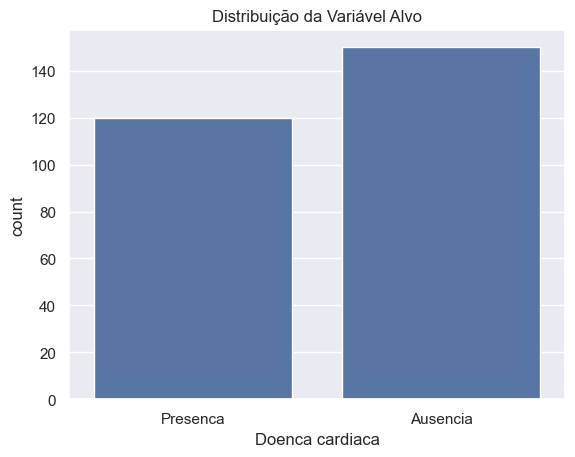

In [40]:
sns.countplot(data=dados, x='Doenca cardiaca')
plt.title('Distribuição da Variável Alvo')
plt.show()

# 3. Divisão dos Dados + Pré-Processamento

### 🔤 Codificação da Variável Alvo

A variável alvo (`Doenca_cardiaca`) foi transformada para formato numérico utilizando `LabelEncoder`, convertendo as categorias em valores binários (0 e 1), o que permite sua utilização em modelos de classificação.

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dados['Doenca cardiaca'] = le.fit_transform(dados['Doenca cardiaca'])

In [42]:
dados['Doenca cardiaca'].unique()

array([1, 0])

### 🧩 Separação entre Variáveis (X e y)

O dataset foi dividido em:

- **X:** variáveis explicativas (features)  
- **y:** variável alvo (`Doenca_cardiaca`)  

Essa separação é essencial para o treinamento supervisionado dos modelos.

In [43]:
X = dados.drop('Doenca cardiaca', axis=1)

y = dados['Doenca cardiaca']

### 🔀 Divisão em Treino e Teste

Os dados foram divididos em conjuntos de treino e teste, utilizando uma proporção de **80% para treino** e **20% para teste**.

Foi aplicada a técnica de **estratificação**, garantindo que a distribuição das classes fosse mantida em ambos os conjuntos, proporcionando uma avaliação mais consistente do modelo.

In [44]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)

## ⚙️ Pré-Processamento dos Dados

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 📏 Padronização das Variáveis

Foi aplicado um processo de **padronização dos dados** utilizando o `StandardScaler`, com o objetivo de colocar todas as variáveis na mesma escala.

Essa técnica transforma os dados para que tenham:

- Média igual a 0  
- Desvio padrão igual a 1  


In [46]:
pre_processamento = Pipeline([
    ('scaler', StandardScaler())
])

### 🔄 Aplicação via Pipeline

A padronização foi implementada por meio de um `Pipeline`, garantindo um fluxo organizado e evitando vazamento de dados (data leakage).

O ajuste (`fit_transform`) foi realizado apenas nos dados de treino, enquanto os dados de teste foram transformados utilizando os mesmos parâmetros aprendidos.


In [47]:
x_treino_tratado = pre_processamento.fit_transform(x_treino)
x_teste_tratado = pre_processamento.transform(x_teste)

In [48]:
X_treino = pd.DataFrame(x_treino_tratado, columns=list(x_treino.columns))
X_teste = pd.DataFrame(x_teste_tratado, columns=list(x_teste.columns))

In [49]:
X_treino.head()

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia
0,-1.163887,-1.491268,-0.209821,-0.710529,-0.128465,-0.424650,-1.042594,-0.051775,-0.714485,-0.655584,0.675659,0.391431,-0.880312
1,-0.037545,-1.491268,-1.263806,0.096320,0.745205,2.354879,0.968123,0.388519,1.399609,-0.912117,-0.964143,0.391431,-0.880312
2,-0.037545,-1.491268,-0.209821,0.269217,1.049091,2.354879,-1.042594,0.872842,-0.714485,-0.912117,-0.964143,-0.692532,-0.880312
3,1.651969,-1.491268,-2.317790,0.557377,-0.185444,-0.424650,-1.042594,0.036283,-0.714485,0.627080,-0.964143,1.475395,-0.880312
4,-2.853402,0.670570,-1.263806,-0.018944,-0.850194,-0.424650,0.968123,2.281783,-0.714485,-0.912117,-0.964143,-0.692532,-0.880312


# 4. Modelos de Machine Learning

## 🤖 Modelo Regressão Logística

A Regressão Logística foi utilizada como modelo base para classificação, com ajuste de peso das classes (`class_weight="balanced"`) para lidar com possíveis desbalanceamentos.


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [51]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter


### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.85  
- **F1-score:** 0.85  
- **Recall (classe 1):** 0.79  

Os resultados indicam bom equilíbrio entre precisão e recall, com desempenho consistente entre as classes.


In [52]:
y_pred_lr = modelo_lr.predict(X_teste)
resultados_lr = classification_report(y_teste, y_pred_lr)
print(resultados_lr)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.86      0.79      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54




### 🔍 Matriz de Confusão

A matriz de confusão mostra:

- Boa capacidade de identificar corretamente ambas as classes  
- Alguns falsos negativos (classe 1), indicando espaço para melhoria no recall  


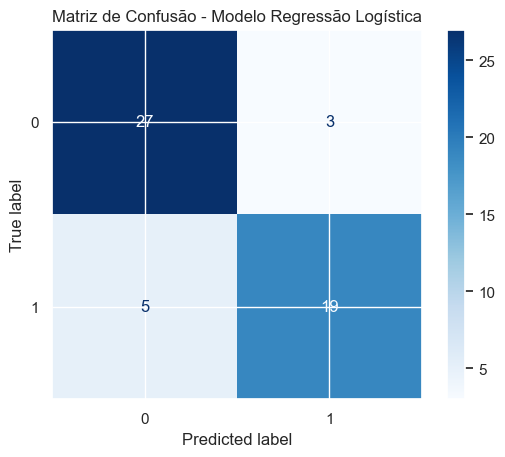

In [53]:
ConfusionMatrixDisplay.from_estimator(modelo_lr, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo Regressão Logística')
plt.show()


### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.94**, indicando excelente capacidade de separação entre as classes.


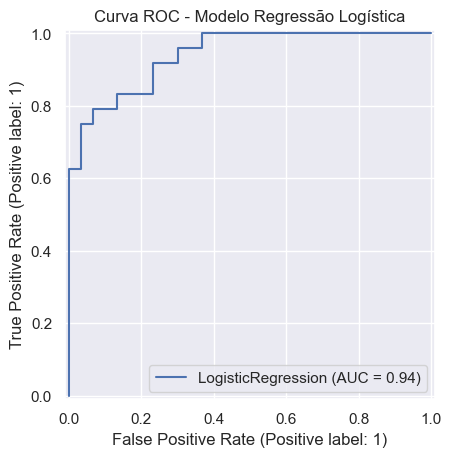

In [54]:
RocCurveDisplay.from_estimator(modelo_lr, X_teste, y_teste)
plt.title('Curva ROC - Modelo Regressão Logística')
plt.show()

## 🌳 Modelo Random Forest

O modelo Random Forest foi aplicado com controle de profundidade (`max_depth=5`) e balanceamento de classes, visando reduzir overfitting e melhorar a generalização.


In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
modelo_rf = RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=123)
modelo_rf.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.85  
- **F1-score:** 0.85  
- **Recall (classe 1):** 0.79  

O desempenho foi equivalente ao da Regressão Logística, indicando boa estabilidade entre diferentes abordagens.


In [57]:
y_pred_rf = modelo_rf.predict(X_teste)
resultados_rf = classification_report(y_teste, y_pred_rf)
print(resultados_rf)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.86      0.79      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



### 🔍 Matriz de Confusão

A matriz de confusão evidencia:

- Boa taxa de acerto para ambas as classes  
- Presença de falsos negativos, similar ao modelo anterior  


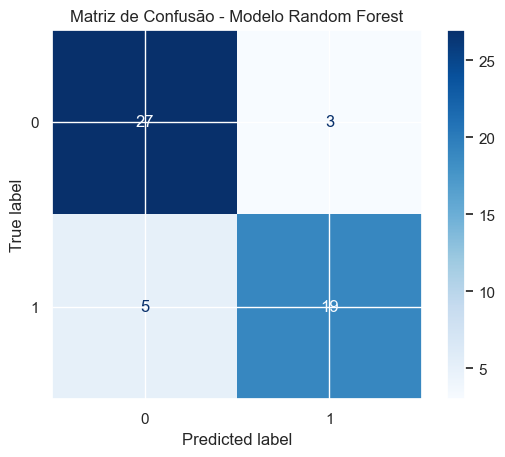

In [58]:
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo Random Forest')
plt.show()

### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.93**, demonstrando excelente capacidade de separação entre as classes.


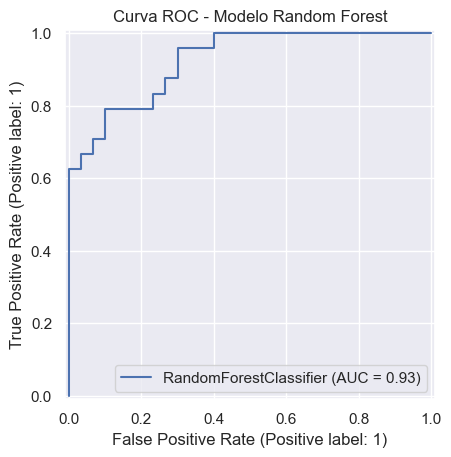

In [59]:
RocCurveDisplay.from_estimator(modelo_rf, X_teste, y_teste)
plt.title('Curva ROC - Modelo Random Forest')
plt.show()

##⚡ Modelo XGBoost

O modelo XGBoost foi aplicado como uma abordagem mais avançada baseada em boosting, capaz de capturar relações mais complexas entre as variáveis.


In [60]:
import xgboost as xgb

In [61]:
modelo_xgb = xgb.XGBClassifier()
modelo_xgb.fit(X_treino, y_treino)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.80  
- **F1-score:** 0.80  
- **Recall (classe 1):** 0.75  

O desempenho foi inferior aos modelos anteriores, indicando menor capacidade de generalização neste problema específico.


In [62]:
y_pred_xgb = modelo_xgb.predict(X_teste)
resultados_xgb = classification_report(y_teste, y_pred_xgb)
print(resultados_xgb)

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        30
           1       0.78      0.75      0.77        24

    accuracy                           0.80        54
   macro avg       0.79      0.79      0.79        54
weighted avg       0.80      0.80      0.80        54



### 🔍 Matriz de Confusão

A matriz de confusão mostra:

- Maior número de erros em comparação aos outros modelos  
- Aumento de falsos negativos e falsos positivos  


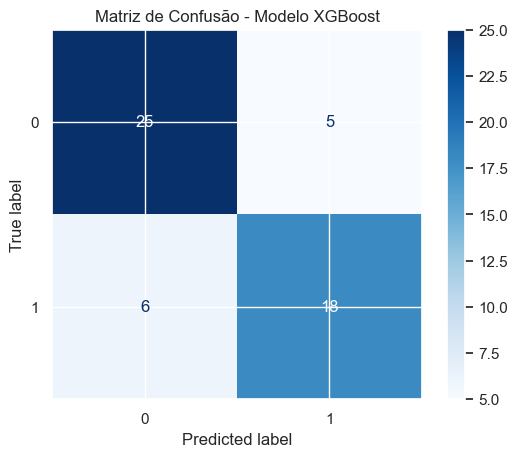

In [63]:
ConfusionMatrixDisplay.from_estimator(modelo_xgb, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo XGBoost')
plt.show()

### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.91**, ainda indicando boa separação entre classes, porém inferior aos demais modelos.


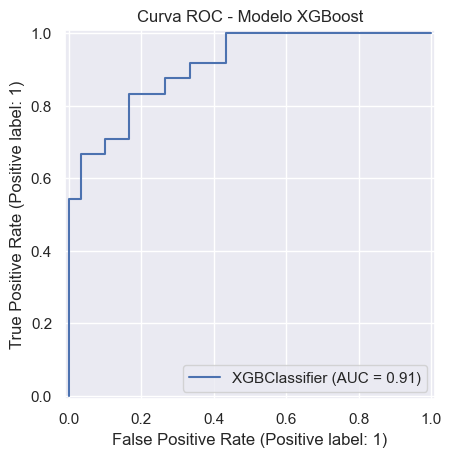

In [64]:
RocCurveDisplay.from_estimator(modelo_xgb, X_teste, y_teste)
plt.title('Curva ROC - Modelo XGBoost')
plt.show()

### Otimização com Grid Search (Random Forest)

Para melhorar o desempenho do modelo, foi aplicado o GridSearchCV no algoritmo Random Forest, com foco na otimização do recall, priorizando a identificação da classe positiva.

Além disso, foi utilizado o parâmetro `class_weight='balanced'`, visando lidar com o desbalanceamento das classes.

Os melhores parâmetros encontrados foram:

- n_estimators: 100  
- max_depth: 5  
- min_samples_split: 2  
- min_samples_leaf: 4  
- bootstrap: True  

Conclusão:
A otimização permitiu encontrar uma configuração mais equilibrada do modelo, melhorando sua capacidade de generalização e a detecção da classe de interesse.

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
# Modelo base
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Definição do grid de parâmetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True],

}

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # pode trocar por 'accuracy' ou 'recall'
    n_jobs=-1,
    verbose=1
)

# Treinando
grid_rf.fit(X_treino, y_treino)

# Melhor modelo
print("Melhores parâmetros:", grid_rf.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Melhores parâmetros: {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [67]:
best_grid = grid_rf.best_estimator_


### ⚙️ Ajuste do Limiar de Decisão

Além da otimização dos hiperparâmetros, foi realizado ajuste manual do **threshold (limiar de decisão)**, reduzido para **0.40**.

Essa abordagem permite aumentar a sensibilidade do modelo, tornando-o mais eficiente na identificação de casos positivos.


In [68]:
y_prob = best_grid.predict_proba(X_teste)[:, 1]

In [69]:
limiar = 0.40
y_pred_ajustado = (y_prob >= limiar).astype(int)

### 📊 Desempenho do Modelo Ajustado


O modelo ajustado apresentou os seguintes resultados:

- Recall (classe 1): 0.83  
- Precision (classe 1): 0.80  
- F1-score (classe 1): 0.82  

Observa-se um bom equilíbrio entre precision e recall, indicando que o modelo consegue identificar a classe positiva de forma consistente, sem comprometer excessivamente a taxa de falsos positivos.

Conclusão:
O modelo apresenta desempenho estável e capacidade adequada de generalização, sendo eficaz na identificação da classe de interesse.


In [70]:
resultados_grid = classification_report(y_teste, y_pred_ajustado)
print(resultados_grid)

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



### 🔍 Matriz de Confusão

A matriz de confusão mostra que o modelo apresenta bom desempenho geral, com:

- Alta quantidade de verdadeiros positivos e verdadeiros negativos  
- Baixo número de falsos negativos  
- Presença moderada de falsos positivos  


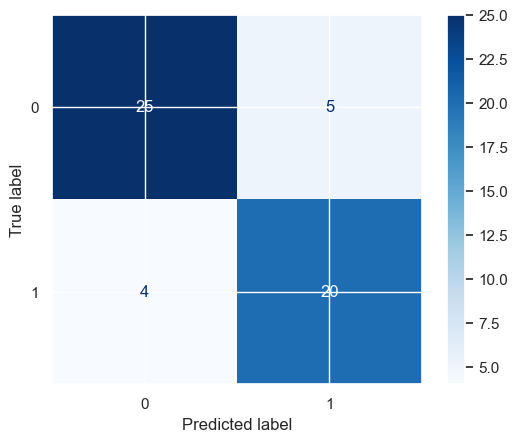

In [71]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_ajustado, cmap='Blues')
plt.show()


### 📈 Curva ROC

A curva ROC apresenta um AUC de aproximadamente 0.83, indicando boa capacidade do modelo em distinguir entre as classes.

O resultado demonstra um equilíbrio adequado entre taxa de verdadeiros positivos (sensibilidade) e falsos positivos.

Conclusão:
O modelo possui bom poder discriminativo, sendo eficaz na separação entre as classes.


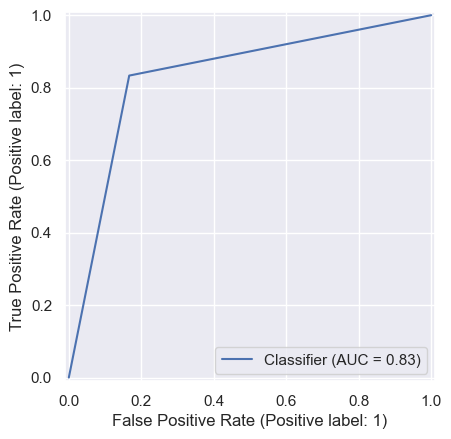

In [72]:
RocCurveDisplay.from_predictions(y_teste, y_pred_ajustado)
plt.show()

### 🧠 Conclusão


A combinação de ajuste de hiperparâmetros e otimização do modelo demonstrou ser eficaz para melhorar o desempenho na identificação da classe de interesse.

O modelo apresentou bom equilíbrio entre precision e recall, além de capacidade consistente de generalização.

Essa abordagem é especialmente relevante em cenários onde a correta identificação da classe positiva é prioritária, contribuindo para decisões mais assertivas.

## 💾 Salvamento do Modelo e Pipeline

Após a etapa de modelagem e otimização, o modelo final e o pipeline de pré-processamento foram salvos utilizando a biblioteca `joblib`.


In [73]:
import joblib

In [74]:
joblib.dump(pre_processamento, 'preprocessamento.pkl')

['preprocessamento.pkl']

In [75]:
joblib.dump(best_grid, 'modelo_classificacao.pkl')

['modelo_classificacao.pkl']